In [1]:
import random
import numpy as np
import pandas as pd
import dqn
import yfinance as yf
# import drqn
import dqn_markov
import drqn


random.seed(10)
TEST_RATIO = 1
# ── paths ─────────────────────────────────────────────────────────────
CSV_A = '../dataset/CORN_USD_2005_2020.csv'   # ← change to your file
CSV_B = '../dataset/WHEAT_USD_2005_2020.csv'   # ← change to your file
CSV_C = '../data-scripts/data.csv'
CSV_D = '../data-scripts/data_one_regime.csv'
# ─────────────────────────────────────────────────────────────────────
df_as = []
df_bs = []
df_a_1 = pd.read_csv(CSV_A).dropna()
df_b_1 = pd.read_csv(CSV_B).dropna()
df_a_1 = df_a_1[int(0.2*len(df_a_1)):int(0.7*len(df_a_1))]
df_b_1 = df_b_1[int(0.2*len(df_b_1)):int(0.7*len(df_b_1))]

df_a_5 = pd.read_csv(CSV_A).dropna()
df_b_5 = pd.read_csv(CSV_B).dropna()
df_a_5 = df_a_5[int(0.2*len(df_a_5)):int(0.9*len(df_a_5))]
df_b_5 = df_b_5[int(0.2*len(df_b_5)):int(0.9*len(df_b_5))]


df_a_2 = pd.read_csv(CSV_C)[['s1']].dropna()
df_b_2 = pd.read_csv(CSV_C)[['s2']].dropna()
df_a_2 = df_a_2.rename(columns={"s1": "close"})
df_b_2 = df_b_2.rename(columns={"s2": "close"})

df_a_3 = pd.read_csv(CSV_D)[['s1']].dropna()
df_b_3 = pd.read_csv(CSV_D)[['s2']].dropna()
df_a_3 = df_a_3.rename(columns={"s1": "close"})
df_b_3 = df_b_3.rename(columns={"s2": "close"})

df_a_4 = yf.download("EOG", period="max", multi_level_index=False)[["Close"]].rename(columns={"Close": "close"})
df_b_4 = yf.download("XOM", period="max", multi_level_index=False)[["Close"]].rename(columns={"Close": "close"})
startindind = max(df_a_4.index.min(), df_b_4.index.min())
df_a_4, df_b_4 = df_a_4.loc[startindind:], df_b_4.loc[startindind:]

df_as = [df_a_1]
df_bs = [df_b_1]
for i in range(len(df_as)):
    df_as[i]=df_as[i][:int(TEST_RATIO*len(df_as[i]))]
    df_bs[i]=df_bs[i][:int(TEST_RATIO*len(df_bs[i]))]

agents = [dqn_markov, dqn]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [2]:

iters = 20
seed_rng = random.Random(12)
arrs = np.zeros((3, 3, iters))
sharpe_ratios = np.zeros((3, 3, iters))
for j in range(len(agents)):
    for i in range(len(df_as)):
        for it in range(iters):
            ag, ret, shr = agents[j].dqn(df_as[i], df_bs[i], seed_rng.randint(0, 10000000))
            arrs[j][i][it]=ret
            sharpe_ratios[j][i][it]=shr

Episode   10/400  return= -99.985  avg10= -99.987  ε=0.951  mem=50000
Episode   20/400  return= -99.983  avg10= -99.983  ε=0.905  mem=50000
Episode   30/400  return= -99.978  avg10= -99.978  ε=0.860  mem=50000
Episode   40/400  return= -99.958  avg10= -99.969  ε=0.818  mem=50000
Episode   50/400  return= -99.945  avg10= -99.951  ε=0.778  mem=50000
Episode   60/400  return= -99.929  avg10= -99.941  ε=0.740  mem=50000
Episode   70/400  return= -99.959  avg10= -99.939  ε=0.704  mem=50000
Episode   80/400  return= -99.851  avg10= -99.886  ε=0.670  mem=50000
Episode   90/400  return= -99.826  avg10= -99.881  ε=0.637  mem=50000
Episode  100/400  return= -99.843  avg10= -99.841  ε=0.606  mem=50000
Episode  110/400  return= -99.648  avg10= -99.762  ε=0.576  mem=50000
Episode  120/400  return= -99.741  avg10= -99.775  ε=0.548  mem=50000
Episode  130/400  return= -99.706  avg10= -99.697  ε=0.521  mem=50000
Episode  140/400  return= -99.824  avg10= -99.695  ε=0.496  mem=50000
Episode  150/400  re

KeyboardInterrupt: 

In [ ]:
for j in range(len(agents)):
    for i in range(len(df_as)):
        print("Returns: Agent number " + str(j) + " on data number " + str(i) + " achieved mean " + str(np.mean(arrs[j][i])) + " and sd " + str(np.std(arrs[j][i])))
        print("Sharpe ratio: Agent number " + str(j) + " on data number " + str(i) + " achieved mean " + str(np.mean(sharpe_ratios[j][i])) + " and sd " + str(np.std(sharpe_ratios[j][i])))

Returns: Agent number 0 on data number 0 achieved mean 8.743727515580911 and sd 16.117030496280933
Sharpe ratio: Agent number 0 on data number 0 achieved mean 0.41146600419204243 and sd 0.6062503076778707
Returns: Agent number 1 on data number 0 achieved mean 0.7983505506779665 and sd 9.280695959870027
Sharpe ratio: Agent number 1 on data number 0 achieved mean 0.1288629252895928 and sd 0.5259195772261043


5.428321068506536
9.322358879379083


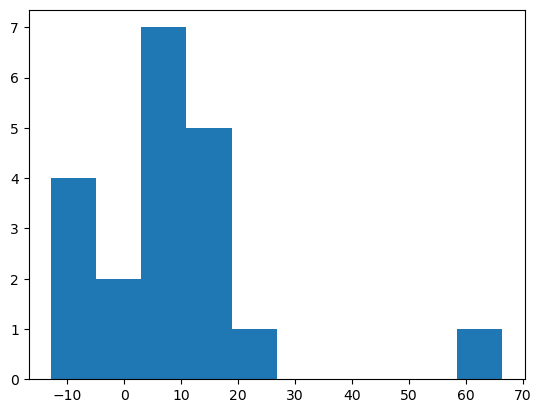

In [ ]:
import matplotlib.pyplot as plt
plt.hist(arrs[0][0], bins=10)
arisq = np.array(arrs[0][0])
arisq[4]=0
print(np.mean(arisq))
print(np.std(arisq))

In [ ]:
sharpe_ratios[1][0][9]=0
print(sharpe_ratios[1][0])
print((np.sum(sharpe_ratios[1][0][:9])+np.sum(sharpe_ratios[1][0][10:]))/19.0)

[-0.37446488  0.42517318 -0.30879107  1.17708168  0.13289021 -0.28077748
 -0.61167218  0.58612075 -0.33751012  0.         -0.19240447  0.28903051
  0.17075443  0.05597179  1.27902289 -0.6208991   0.68261607 -0.35340198
  0.44219529  0.41632298]
0.13564518451536087


20 iterations: dqn_markov and dqn
Returns: Agent number 0 on data number 0 achieved mean 8.743727515580911 and sd 16.117030496280933
Sharpe ratio: Agent number 0 on data number 0 achieved mean 0.41146600419204243 and sd 0.6062503076778707
Returns: Agent number 1 on data number 0 achieved mean 0.7983505506779665 and sd 9.280695959870027
Sharpe ratio: Agent number 1 on data number 0 achieved mean 0.1288629252895928 and sd 0.5259195772261043

agents are: drqn, markov_dqn, dqn

data is: real data, fake data

Returns: Agent number 0 on data number 0 achieved mean 10.896607740817691 and sd 12.431501508650333
Sharpe ratio: Agent number 0 on data number 0 achieved mean 0.6348567843685814 and sd 0.6542641930507017
Returns: Agent number 0 on data number 1 achieved mean 488.47282458015707 and sd 376.92757062696427
Sharpe ratio: Agent number 0 on data number 1 achieved mean 6.575417074307637 and sd 2.7769001138986704
Returns: Agent number 1 on data number 0 achieved mean 8.711434058757543 and sd 9.9910648771881
Sharpe ratio: Agent number 1 on data number 0 achieved mean 0.6474192621787337 and sd 0.6849166945994932
Returns: Agent number 1 on data number 1 achieved mean 668.761653078647 and sd 238.84014117738877
Sharpe ratio: Agent number 1 on data number 1 achieved mean 6.47383389543771 and sd 0.9405731399268835
Returns: Agent number 2 on data number 0 achieved mean 8.031064441914902 and sd 3.8882453044146605
Sharpe ratio: Agent number 2 on data number 0 achieved mean 1.126560272441609 and sd 1.0174903270941151
Returns: Agent number 2 on data number 1 achieved mean 1775.8480488369921 and sd 1388.805809370478
Sharpe ratio: Agent number 2 on data number 1 achieved mean 8.782413090177473 and sd 2.632360582747643